In [1]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2025-08-15 11:40:40--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.06s   

2025-08-15 11:40:40 (17.0 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [2]:
with open("input.txt", "r", encoding="utf-8") as f:
  text = f.read()

In [3]:
print(len(text))

1115394


In [4]:
print(text[:1_000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [5]:
chars = sorted(set(text))
vocab_size = len(chars)
print("".join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [6]:
stoi = {ch:i for i, ch in enumerate(chars)}
itos = {i:ch for ch, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

print(encode("Hello, friend"))
print(decode(encode("Hello, friend")))

[20, 43, 50, 50, 53, 6, 1, 44, 56, 47, 43, 52, 42]
Hello, friend


In [7]:
import torch
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1_000])

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [8]:
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

In [9]:
block_size = 8
train_data[:block_size + 1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [10]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
  context = x[:t+1]
  target = y[t]
  print(f"when input is {context} the target is: {target}")

when input is tensor([18]) the target is: 47
when input is tensor([18, 47]) the target is: 56
when input is tensor([18, 47, 56]) the target is: 57
when input is tensor([18, 47, 56, 57]) the target is: 58
when input is tensor([18, 47, 56, 57, 58]) the target is: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target is: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target is: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target is: 58


In [11]:
torch.manual_seed(1337)
batch_size = 4
block_size = 8

def get_batch(split):
  data = train_data if split == "train" else val_data
  ix = torch.randint(len(data) - block_size, (batch_size,))
  x = torch.stack([data[i:i+block_size] for i in ix])
  y = torch.stack([data[i+1:i+block_size+1] for i in ix])
  return x, y

xb, yb = get_batch("train")
print("inputs:")
print(xb.shape)
print(xb)
print("targets:")
print(yb.shape)
print(yb)

print("----")

for b in range(batch_size):
  for t in range(block_size):
    context = xb[b, :t+1]
    target = yb[b, t]
    print(f"When input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
----
When input is [24] the target: 43
When input is [24, 43] the target: 58
When input is [24, 43, 58] the target: 5
When input is [24, 43, 58, 5] the target: 57
When input is [24, 43, 58, 5, 57] the target: 1
When input is [24, 43, 58, 5, 57, 1] the target: 46
When input is [24, 43, 58, 5, 57, 1, 46] the target: 43
When input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
When input is [44] the target: 53
When input is [44, 53] the target: 56
When input is [44, 53, 56] the target: 1
When input is [44, 53, 56, 1] the target: 58
When input is [44, 53, 56, 1, 58] the target: 46
When input is [44, 53

**I skip bigram LM, because I already implemented it and it serves as a baseline**

In [12]:
torch.manual_seed(1337)
B, T, C = 4, 8, 2  # Batch, time, channels
x = torch.randn(B, T, C)
x.shape

torch.Size([4, 8, 2])

In [13]:
"""
THE WEAKEST FORM OF AGGREGATION - AVERAGING
"""
xbow = torch.zeros((B, T, C))
for b in range(B):
  for t in range(T):
    xprev = x[b, :t+1]  # (t, C)
    xbow[b, t] = torch.mean(xprev, 0)  # mean along time dimension

In [16]:
# However, we can be mathematically efficient
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
b = torch.randint(0, 10, (3, 2)).float()
c = a @ b
print("a=")
print(a)
print("--")
print("b=")
print(b)
print('--')
print("c=")
print(c)

a=
tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[ 2.,  7.],
        [ 8., 11.],
        [14., 16.]])


As you can see, our (t, c) dotproduct now acts as a running sum. This is how dot product works, elementwise row a by column b summed up

In [17]:
# Now, let's take a mean
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, dim=1, keepdim=True)
b = torch.randint(0, 10, (3, 2)).float()
c = a @ b
print("a=")
print(a)
print("--")
print("b=")
print(b)
print('--')
print("c=")
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [18]:
# Here's how we'll use it
wei = torch.tril(torch.ones(T, T))  # For each character, each token's weight
wei = wei / wei.sum(dim=1, keepdim=True)
xbow2 = wei @ x  # (T, T) @ (B, T, C) -> (B, T, C)

In [22]:
import torch.nn.functional as F

In [23]:
# Technical detail:
# In attention mechanism we use softmax to give attention scores to tokens
# We can't apply masking after softmax (that way, dim won't sum to 1.0)
# So we use -inf instead of 0s

tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T, T))
wei = wei.masked_fill(tril == 0, float("-inf"))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x

### **Self-Attention**

In [24]:
torch.manual_seed(1337)
B, T, C = 4, 8, 32  # Batch, Time, Channels
x = torch.randn(B, T, C)

tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T, T))
wei = wei.masked_fill(tril == 0, float("-inf"))
wei = F.softmax(wei, dim=-1)
out = wei @ x
out.shape

torch.Size([4, 8, 32])

Self-Attention uses a very smart approach. It gives each token 2 vectors:

- **Q** - Query. What Am I looking for?
- **K** - Key. What do I contain?

Q @ K - Shows alignment degree. The more aligned the vector K_k is to Q_i, the more i attends to j

In [27]:
from torch import nn

In [30]:
x.shape

torch.Size([4, 8, 32])

In [31]:
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)

k = key(x)  # (B, T, 16)
q = query(x)  # (B, T, 16)

In [32]:
# wei = q @ k Doesn't work, because (B, T, 16) @ (B, T, 16) won't work out
wei = q @ k.transpose(-2, -1)  # (B, T, 16) @ (B, 16, T)  -> (B, T, T)

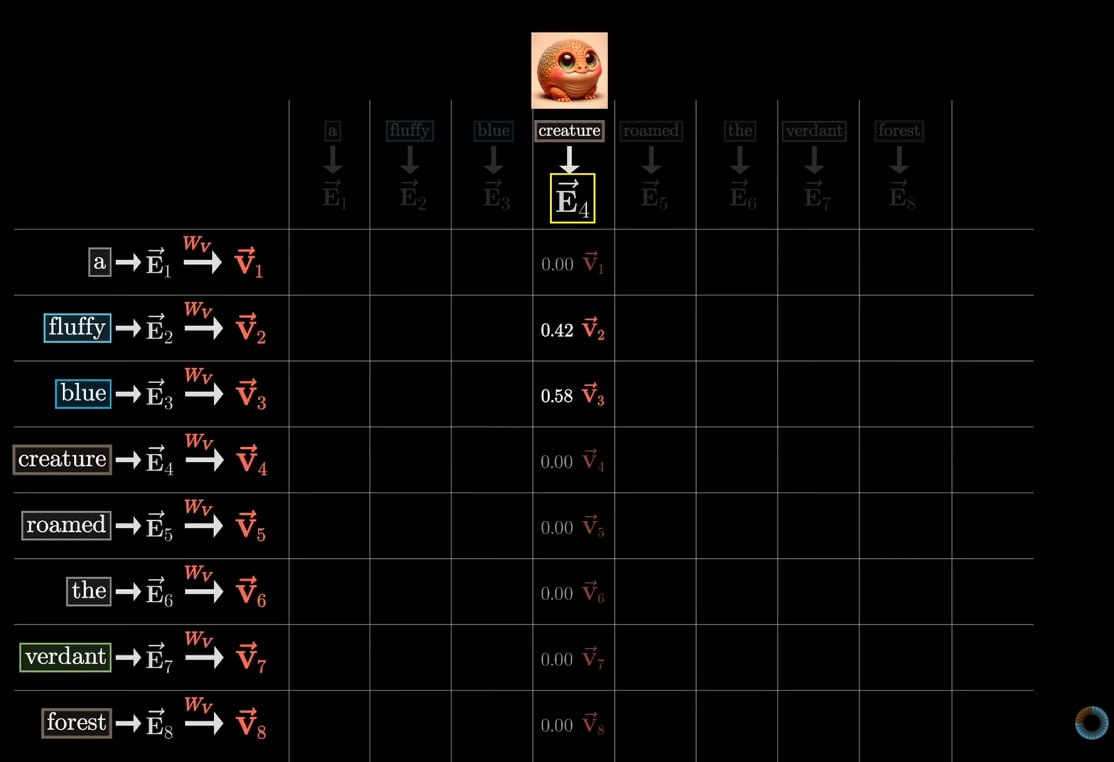

I really, truly, very like the way Grant depicted this T, T table in his "Attention in transformers, step-by-step | Deep Learning Chapter 6" video

In [34]:
# Let's apply softmax!
tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float("-inf"))
wei = F.softmax(wei, dim=-1)
out = wei @ x

In [35]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

Sweet! It's pretty much the same thing, but weights are not uniformal. They're data dependent!

In [39]:
# however, raw x multiplication is not a thing
# We introduce V (value)
# V - value. Selective meaning for this particular k and q

head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)  # (B, T, 16)
q = query(x)  # (B, T, 16)

wei = q @ k.transpose(-2, -1) * head_size**-0.5  # Preserves variance and provides stability
tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float("-inf"))
wei = F.softmax(wei, dim=-1)

v = value(x)  # Value Calculation!

out = wei @ v  # (B, T, T) @ (B, T, 16) -> (B, T, 16)

**That's it here. The crux implemented, the rest in the video is bigram related and the stuff I already know. Thanks to Andrej❤️**